In [238]:
import datetime as dt
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import numpy as np
from skfolio.datasets import load_sp500_dataset, load_sp500_implied_vol_dataset
from skfolio.preprocessing import prices_to_returns
from collections import namedtuple
from statsmodels.tsa.stattools import coint
import statsmodels.api as sm

# 1 - Realised Volatility

Get prices from Yahoo finance since ```pandas_datareader``` is no longer supported for latest ```python``` implementations.

In [165]:
def download_prices_yfinance(ticker: str, start: str, end: str) -> pd.DataFrame:
    """Use yfinance to download daily OHLCV from yfinance.
    PDR is not supported for > python 3.11"""
    
    start = pd.to_datetime(start)
    end = pd.to_datetime(end)

    candidates = [
       ticker,
       ticker.upper(),
       f"{ticker}.US",
       f"{ticker.upper()}.US",
       f"{ticker}.us",
       f"{ticker.upper()}.us",
    ]

    last_err = None
    for t in candidates:
        try:
            df = yf.download(t, start=start, end=end, progress=False)
            if df is not None and not df.empty:
                return df
        except Exception as e:
            last_err = e

    raise RuntimeError(
        f"Failed to download data for ticker '{ticker}' from yfinance using yfinance."
        f" Tried candidates: {candidates}. Last error: {last_err}"
    )

def plot_stockprice(stock: pd.Series, ticker: str, name: str) -> None:
    """Plot the stock price over time."""
    plt.figure(figsize=(12, 6))
    plt.plot(stock.index, stock.values, label=ticker)
    plt.title(f"{name} Stock Price")
    plt.xlabel("Date")
    plt.ylabel("Price (USD)")
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()


Simple plot of stock in USD.

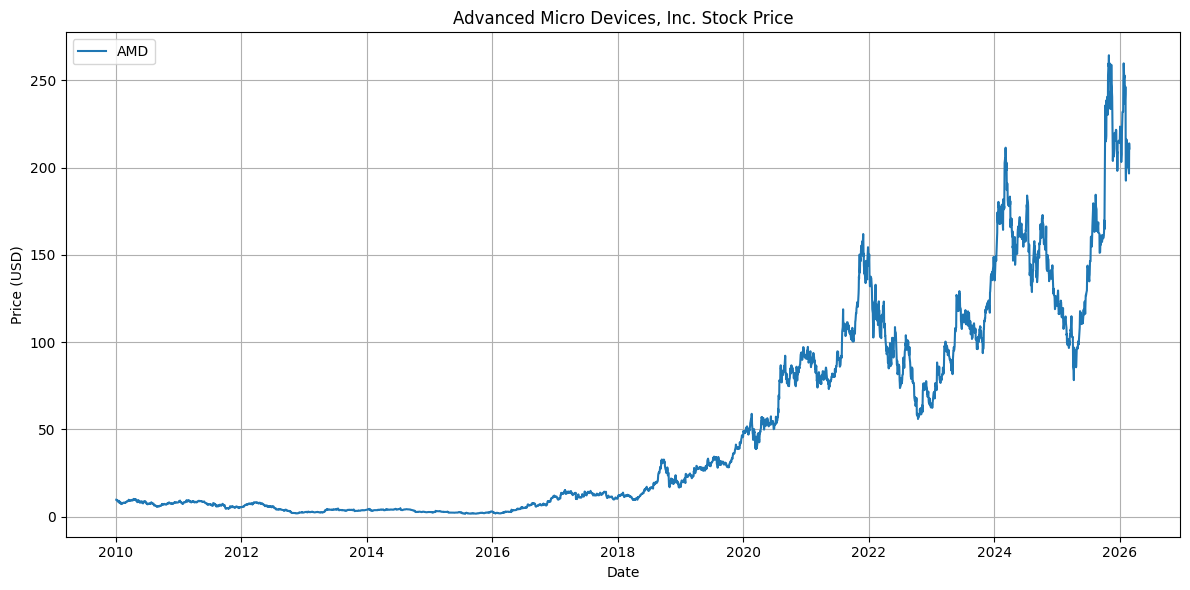

In [166]:
ticker = "AMD"
start_date = "2010-01-01" # implied s&p volatility starts in 2010
end_date = dt.date.today().strftime("%Y-%m-%d")
name = yf.Ticker(ticker).info.get("longName", ticker)

data = download_prices_yfinance(ticker, start_date, end_date)

stock = data["Close"].astype(float)

plot_stockprice(stock, ticker, name)

### Step 3 - Historical Estimators

Implement mean returns, historical, parkinson, and garman-klass volatilities.

In [167]:
def mean_returns(data: pd.DataFrame, window: int = 30) -> pd.DataFrame:
    """Calculates the mean return for every entry in the data frame with a rolling window."""
    stock = data["Close"].astype(float)
    returns = (stock - stock.shift(1)) / stock.shift(1).dropna()
    # assuming constant dt as 1 -> daily data
    mean_return = returns.rolling(window=window).mean().dropna()

    return mean_return
    

def mean_log_returns(data: pd.DataFrame, window: int = 30) -> pd.DataFrame:
    """Calculate the mean log return for every entry in the data frame with a rolling window."""
    stock = data["Close"].astype(float)
    log_returns = np.log(stock / stock.shift(1)).dropna()
    # assuming constant dt as 1 -> daily data
    mean_log_return = log_returns.rolling(window=window).mean()

    return mean_log_return

def historical_volatility(data: pd.DataFrame, window: int = 30) -> pd.DataFrame:
    """Calculate the historical volatility for every entry in the data frame with a rolling window."""
    stock = data["Close"].astype(float)
    returns = stock.pct_change().dropna()
    # assuming constat dt as 1 -> daily data
    sigma = returns.rolling(window=window).std()

    return sigma

def parkinson_volatility(data: pd.DataFrame, window: int = 30) -> pd.DataFrame:
    """Calculate the Parkinson volatility for every entry in the data frame with a rolling window."""
    
    log_hl = np.log(data['High'] / data['Low']).dropna()
    mean = (log_hl**2).rolling(window=window).mean()

    sigma = np.sqrt(mean / (4 * np.log(2)))

    return sigma

def garman_klass_volatility(data: pd.DataFrame, window: int = 30) -> pd.DataFrame:
    """Calculate the Garman-Klass volatility of the stock."""
    log_hl = np.log(data['High'] / data['Low']).dropna()
    log_co = np.log(data['Close'] / data['Open']).dropna()
    
    sigma = np.sqrt(1 / 2 * (log_hl**2).rolling(window=window).mean() 
                    - (2 * np.log(2) - 1) * (log_co**2).rolling(window=window).mean())

    return sigma

Define plot function to compare all metrics against each other.

In [168]:

def plot_metrics(data: pd.DataFrame, sp_returns: pd.Series, sp_imp_vol: pd.Series, ticker: str, name: str, window: int = 30) -> None:
    """Plot the stock price, mean return, mean log return, historical volatility, Parkinson volatility and Garman-Klass volatility."""
    stock = data["Close"].astype(float)
    mean_return = mean_returns(data, window=window)
    mean_log_return = mean_log_returns(data, window=window)
    hist_vol = historical_volatility(data, window=window)
    parkinson_vol = parkinson_volatility(data, window=window)
    gk_vol = garman_klass_volatility(data, window=window)

    fig = plt.figure(figsize=(15, 10), dpi=300)
    gs = fig.add_gridspec(3, 2)
    ax1 = fig.add_subplot(gs[0, :])
    ax2 = fig.add_subplot(gs[1, 0])
    ax3 = fig.add_subplot(gs[1, 1])
    ax4 = fig.add_subplot(gs[2, 0], sharex=ax2)
    ax5 = fig.add_subplot(gs[2, 1], sharex=ax3)
    
    axs = [ax1, ax2, ax3, ax4, ax5]

    axs[0].plot(stock.index, stock.values, label=ticker)
    axs[0].set_title(f"{name} Stock Price")
    axs[0].set_xlabel("Date")
    axs[0].set_ylabel("Price (USD)")
    axs[0].legend()
    axs[0].grid()

    axs[1].plot(mean_return.index, mean_return.values, lw=1, label="Mean Return")
    axs[1].set_title(f"{name} Mean Return (window={window})")
    axs[1].set_xlabel("Date")
    axs[1].set_ylabel("Mean Return")
    axs[1].grid()

    axs[1].plot(mean_log_return.index, mean_log_return.values, lw=1, label="Mean Log Return")
    axs[1].set_title(f"{name} Mean Log Return (window={window})")
    axs[1].set_xlabel("Date")
    axs[1].set_ylabel("Mean Log Return")
    axs[1].grid()

    axs[1].set_title(f"{name} Returns (window={window})")
    axs[1].legend()
    axs[1].grid()

    axs[2].plot(hist_vol.index, hist_vol.values, lw=1, label="Historical Volatility")
    axs[2].set_title(f"{name} Historical Volatility (window={window})")
    axs[2].set_xlabel("Date")
    axs[2].set_ylabel("Historical Volatility")
    axs[2].grid()

    axs[2].plot(parkinson_vol.index, parkinson_vol.values, lw=1, label="Parkinson Volatility")
    axs[2].set_title(f"{name} Parkinson Volatility (window={window})")
    axs[2].set_xlabel("Date")
    axs[2].set_ylabel("Parkinson Volatility")
    axs[2].grid()

    axs[2].plot(gk_vol.index, gk_vol.values, lw=1, label="Garman-Klass Volatility")
    axs[2].set_title(f"{name} Garman-Klass Volatility (window={window})")
    axs[2].set_xlabel("Date")
    axs[2].set_ylabel("Garman-Klass Volatility")
    axs[2].grid()
    axs[2].set_title(f"{name} Volatility Metrics (window={window})")
    axs[2].legend()

    axs[3].plot(sp_returns.index, sp_returns.values, lw=.5, label="S&P 500 Mean Return")
    axs[3].set_title(f"{name} vs S&P 500 Mean Return (window={window})")
    axs[3].set_xlabel("Date")
    axs[3].set_ylabel("Mean Return")
    axs[3].legend()
    axs[3].grid()
    
    axs[4].plot(sp_imp_vol.index, sp_imp_vol.values, lw=1, label="S&P 500 Implied Volatility")
    axs[4].set_title(f"{name} vs S&P 500 Implied Volatility (window={window})")
    axs[4].set_xlabel("Date")
    axs[4].set_ylabel("Implied Volatility")
    axs[4].legend()
    axs[4].grid()

    plt.legend()
    plt.tight_layout()
    plt.suptitle(f"{name} Stock Metrics", y=1.02)


Get implied volatility and prices from S&P 500

In [169]:
sp_prices = load_sp500_dataset()
sp_imp_vol = load_sp500_implied_vol_dataset()
sp_returns = prices_to_returns(sp_prices)
sp_returns = sp_returns.loc[start_date:]
sp_imp_vol.tail()

sp_returns = sp_returns[ticker]
sp_imp_vol = sp_imp_vol[ticker]


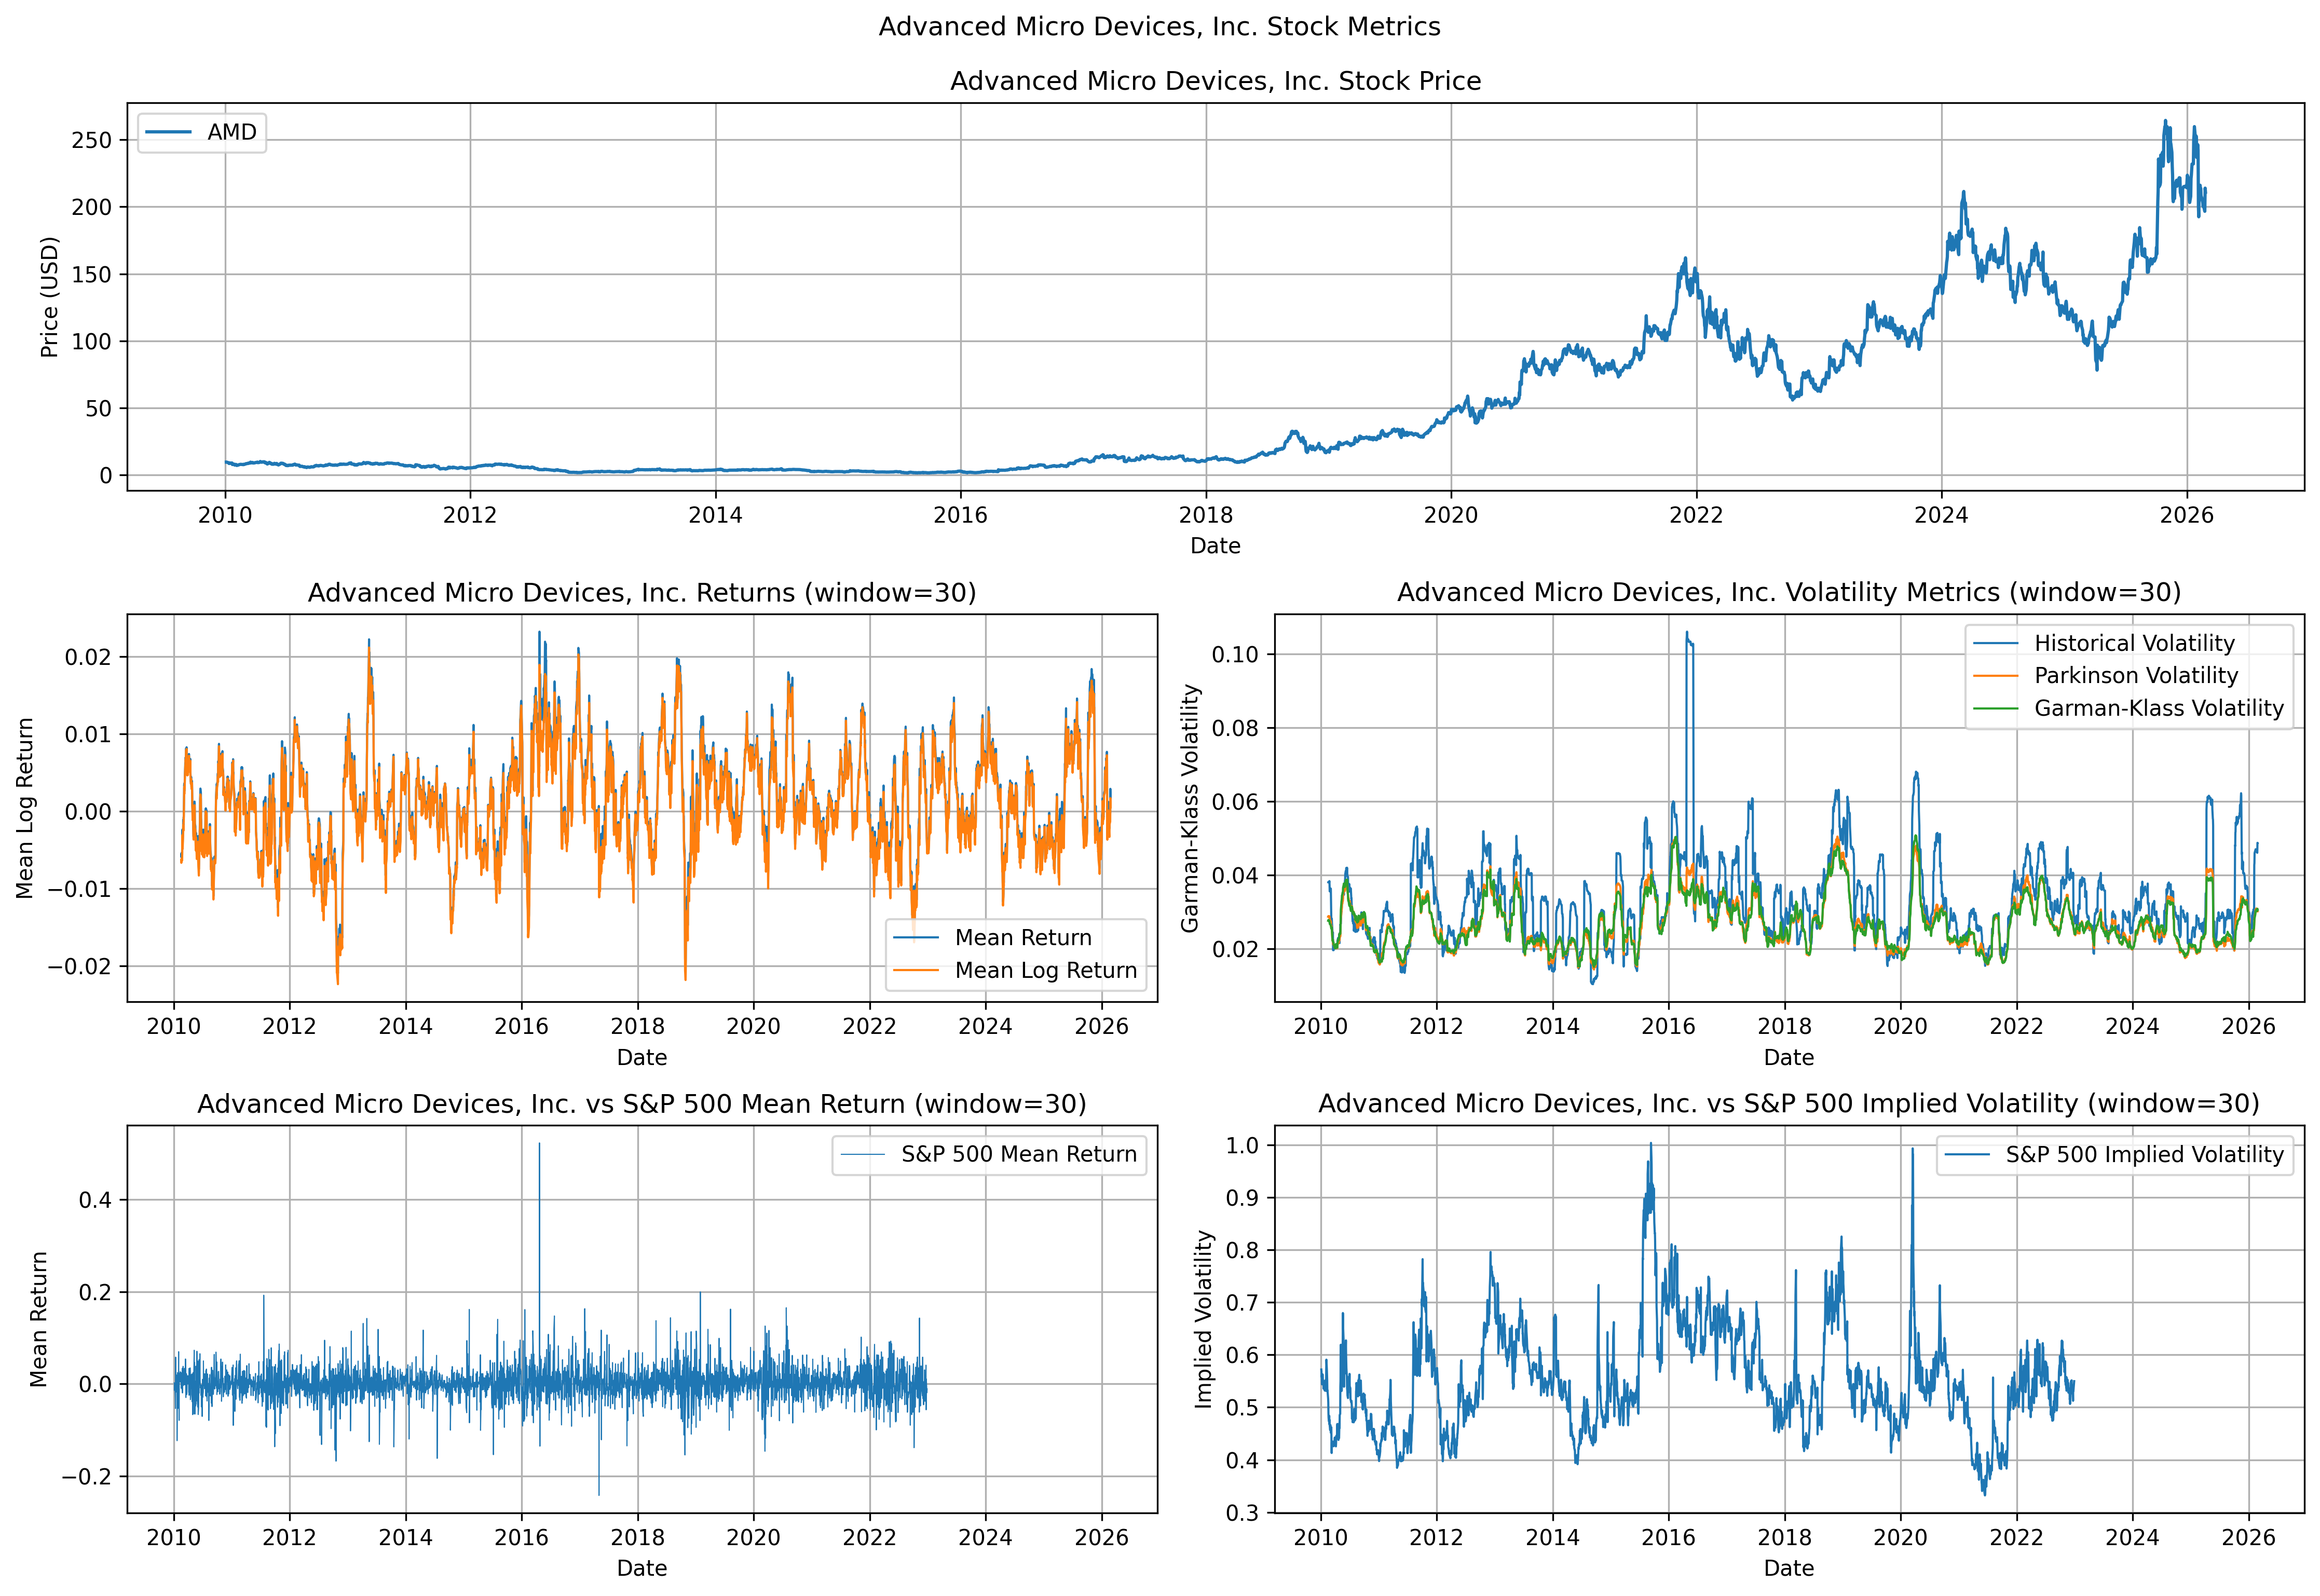

In [170]:
plot_metrics(data, sp_returns, sp_imp_vol, ticker, name, window=30)

Get VIX and SPX data via yfinance

In [171]:
def _fetch_yf_close(symbol: str, start_date: str, end_date: str) -> pd.DataFrame:
    start = pd.to_datetime(start_date)
    end = pd.to_datetime(end_date)

    df = yf.download(
        symbol,
        start=start,
        end=end,
        progress=False,
        auto_adjust=False,
        threads=False,
    )

    if df is None or df.empty:
        raise RuntimeError(f"No data returned from Yahoo Finance for {symbol}")

    if "Close" not in df.columns:
        raise RuntimeError(f"'Close' column missing for {symbol}")

    close = df[["Close"]].dropna()
    close.index = pd.to_datetime(close.index)
    close = close.sort_index()

    if close.empty:
        raise RuntimeError(f"Close series empty after cleaning for {symbol}")

    return close


def fetch_spx_close(start_date: str, end_date: str) -> pd.DataFrame:
    """
    Fetch S&P 500 daily close from Yahoo Finance.
    Returns DataFrame with 'Close' column and DatetimeIndex.
    """
    return _fetch_yf_close("^GSPC", start_date, end_date)


def fetch_vix_close(start_date: str, end_date: str) -> pd.DataFrame:
    """
    Fetch VIX daily close from Yahoo Finance.
    Returns DataFrame with 'Close' column and DatetimeIndex.
    """
    return _fetch_yf_close("^VIX", start_date, end_date)

In [172]:
end_date_vix = pd.to_datetime("today") 
start_date_vix = end_date_vix - pd.Timedelta(days=365) # 1 year back from end date

spx_close = fetch_spx_close(start_date_vix, end_date_vix)
vix_close = fetch_vix_close(start_date_vix, end_date_vix)
spx_symbol = "SPX"

lastBusDay = spx_close.index[-1]
print(f"LBD\t {lastBusDay.date()}")
so = float(spx_close["Close"].iloc[-1].values[0])
vix_market = float(vix_close["Close"].iloc[0].values[0])

T = 30 / 365
r = 0.02
fo = so * np.exp(r * T) # forward approx
print(f"SO \t {so:.2f} USD \nFO \t {fo:.2f} USD\nVIX\t {vix_market:.2f} USD")


LBD	 2026-02-26
SO 	 6877.48 USD 
FO 	 6888.79 USD
VIX	 19.10 USD


Yahoo finance does not provide options for index tickers. To approximate, we use SPY as a tradable SPX ETF proxy

In [173]:
spy_ticker = yf.Ticker("SPY")

expirations = spy_ticker.options
assert expirations is not None and len(expirations) > 0, "No options expirations found for SPY"

expirations = sorted(pd.to_datetime(expirations).strftime("%Y-%m-%d").tolist())
# 30 day expiry from end date
expiry = end_date_vix + pd.Timedelta(days=30)
# find closest expiry to 30 days from end date
expiry = min(expirations, key=lambda x: abs(pd.to_datetime(x) - pd.to_datetime(expiry)))

print(f"Expiry: {expiry}")

# option chain
oc = spy_ticker.option_chain(expiry)

Expiry: 2026-03-27


Build the VIX estimator

In [174]:
def _clean_strikes(df: pd.DataFrame) -> pd.DataFrame:
    """Clean the strikes and mid prices in the options DataFrame."""
    df = df[["strike", "mid"]].dropna()
    df["strike"] = df["strike"].astype(float)
    df = df.sort_values("strike")
    return df

def _add_mid_prices(df: pd.DataFrame) -> pd.DataFrame:
    """Add mid price column to the options DataFrame."""
    df = df.copy()
    df["bid"] = df["bid"].astype(float)
    df["ask"] = df["ask"].astype(float)
    df["lastPrice"] = df["lastPrice"].astype(float)
    
    mid = (df["bid"] + df["ask"]) / 2
    # if bid/ask is not available, use last price as mid price
    df["mid"] = mid.where(mid > 0).fillna(df["lastPrice"])

    df = _clean_strikes(df)
    return df


def _put_sum(put_strikes: list, put_price: dict) -> float:
    """Compute the sum of put prices for VIX calculation.
    """
    put_sum = 0.0
    for i in range(len(put_strikes) - 1):
        K_i = put_strikes[i]
        K_next = put_strikes[i + 1]
        P_i = put_price.get(K_i, np.nan)
        if np.isfinite(P_i) and P_i > 0:
            put_sum += P_i * (1 / K_i - 1 / K_next)

    return put_sum

def _call_sum(call_strikes: list, call_price: dict) -> float:
    """Compute the sum of call prices for VIX calculation."""
    call_sum = 0.0 
    for i in range(1, len(call_strikes)):
        K_i = call_strikes[i]
        K_prev = call_strikes[i-1]
        C_i = call_price.get(K_i, np.nan)
        if np.isfinite(C_i) and C_i > 0:
            call_sum += C_i * (1 / K_prev - 1 / K_i)

    return call_sum

def _get_k0(cp: list, F: float) -> float:
    """Calculate the strike K_0 closest to the forward price F at the money."""

    strikes = np.array(sorted(cp["strike"].unique()), dtype=float)
    K_0_candidates = strikes[strikes <= F]
    if len(K_0_candidates) == 0:
        raise RuntimeError("No strikes found that are less than or equal to the forward price F.")
    K_0 = K_0_candidates[-1]  # largest strike less than or equal

    return K_0  


def vix2_estimator(oc: namedtuple, r: float, T: float) -> float:

    # add mid prices ot calls
    calls = _add_mid_prices(oc.calls.copy())
    puts = _add_mid_prices(oc.puts.copy())

    # estimate forward price from call and put mid prices using put-call parity
    cp = pd.merge(calls, puts, on="strike", suffixes=("_call", "_put"))
    if cp.empty:
        raise RuntimeError("No matching strikes found between calls and puts for SPY options.")

    # find strike with smallest absolute difference between call and put mid prices
    cp["abs_diff"] = (cp["mid_call"] - cp["mid_put"]).abs()
    atm = cp.loc[cp["abs_diff"].idxmin()]

    assert T > 0, "Time to maturity T must be positive."
    # strike price at the money
    K_atm = float(atm["strike"])
    F = K_atm + np.exp(r * T) * (atm["mid_call"] - atm["mid_put"])
    K_0 = _get_k0(cp, F)
    
    # build ordered otm strike list
    put_strikes = np.array(sorted(puts.loc[puts["strike"] <= K_0, "strike"].unique()), dtype=float)
    call_strikes = np.array(sorted(calls.loc[calls["strike"] >= K_0, "strike"].unique()), dtype=float)

    if len(put_strikes) < 2 or len(call_strikes) < 2:
        raise RuntimeError("Not enough OTM strikes found for puts or calls to compute the VIX.")

    # get call and put sums    
    put_price = dict(zip(puts["strike"], puts["mid"]))
    call_price = dict(zip(calls["strike"], calls["mid"]))

    put_sum = _put_sum(put_strikes, put_price)
    call_sum = _call_sum(call_strikes, call_price)
    
    # compute vix
    vix2 = 2*np.exp(r * T) / T  *  (put_sum + call_sum)

    return vix2

def vix2_to_cboe_vix(vix2: float) -> float:
    """Convert the VIX^2 estimator to the CBOE VIX index level."""
    if vix2 < 0:
        raise ValueError("VIX^2 cannot be negative.")
    vix = 100 * np.sqrt(vix2)
    return vix


In [175]:
vix2 = vix2_estimator(oc, r, T)

# compute vix since vix2 is squared and in percentage points
vix = vix2_to_cboe_vix(vix2)

print(f"Estimated VIX: {vix:.2f} USD")
print(f"Market VIX: {vix_market:.2f} USD")
print(f"Percentage difference: {abs(vix - vix_market) / vix_market * 100:.2f}%")

Estimated VIX: 18.13 USD
Market VIX: 19.10 USD
Percentage difference: 5.09%


We compare historical VIX market data against the historical estimated realised variance computed earlier.

In [201]:
vix_close = fetch_vix_close(start_date, end_date)

# translate VIX from percentage points to volatility
vix_as_vol = vix_close["Close"] / 100
vix_as_vol.index = pd.to_datetime(vix_as_vol.index)

# historical volatilities must be annualised to match VIX
hist_vol = historical_volatility(data, window=30) * np.sqrt(252) # annualise
hist_parkinson = parkinson_volatility(data, window=30) * np.sqrt(252) # annualise
hist_gk = garman_klass_volatility(data, window=30) * np.sqrt(252) # annualise

# rename value col
vix_as_vol = vix_as_vol.rename(columns={"^VIX":"VIX"})
hist_vol = hist_vol.rename(columns={"AMD":"Hist"})
hist_parkinson = hist_parkinson.rename(columns={"AMD":"Parkinson"})
hist_gk = hist_gk.rename(columns={"AMD":"GK"})

# combine all series into a single DataFrame for correlation analysis
df_merged = pd.concat([vix_as_vol, 
                        hist_vol, 
                        hist_parkinson, 
                        hist_gk], axis=1).dropna()

# correlation
df_corr = df_merged.corr()

# cointegration test
coint_result = {}

# iterate through data frame and calculate stats for all
for col in df_merged.columns:
    if col == "VIX":
        continue
    coint_test = coint(df_merged["VIX"], df_merged[col])
    coint_result[col] = {
        "t_stat": coint_test[0],
        "p_value": coint_test[1],
        "critical_values": coint_test[2]
    }

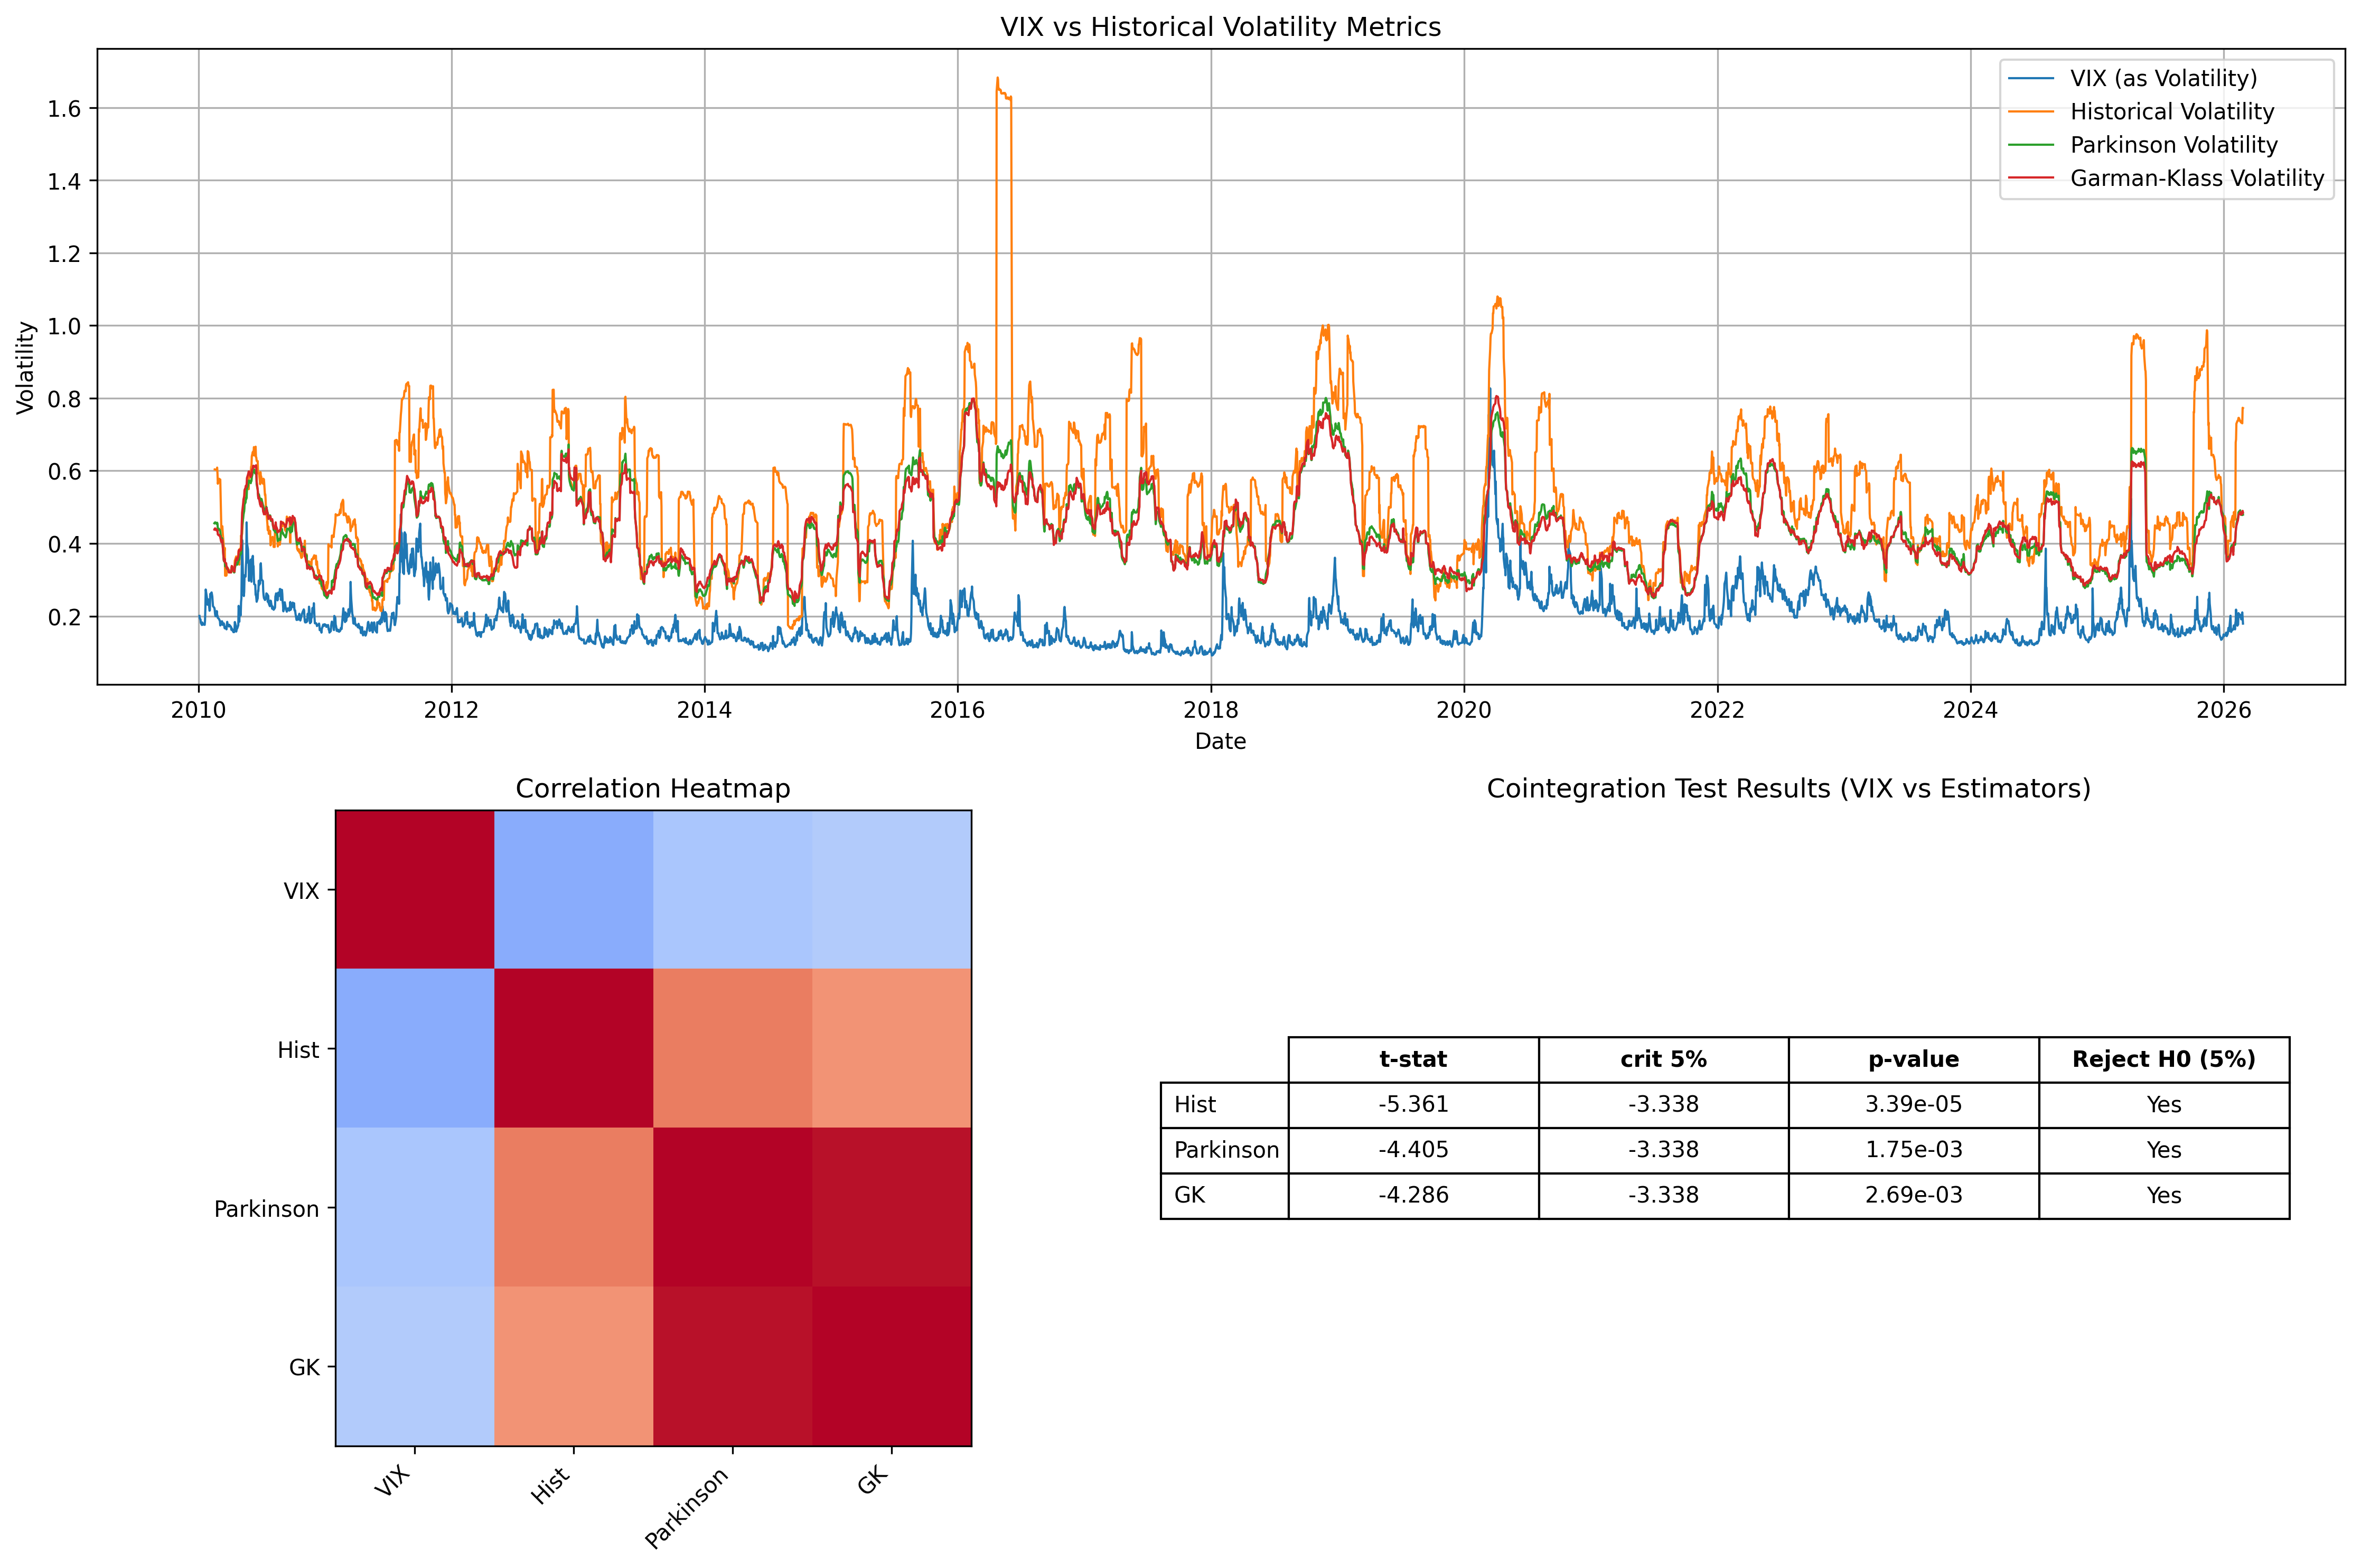

In [237]:

fig = plt.figure(figsize=(15, 10), dpi=300)
gs = fig.add_gridspec(2, 2)
axs1 = fig.add_subplot(gs[0, :])
axs2 = fig.add_subplot(gs[1, 0])
axs3 = fig.add_subplot(gs[1, 1])

# time series
axs1.plot(vix_as_vol.index, vix_as_vol.values, lw=1, label="VIX (as Volatility)")
axs1.plot(hist_vol.index, hist_vol.values, lw=1, label="Historical Volatility")
axs1.plot(hist_parkinson.index, hist_parkinson.values, lw=1, label="Parkinson Volatility")
axs1.plot(hist_gk.index, hist_gk.values, lw=1, label="Garman-Klass Volatility")
axs1.set_title("VIX vs Historical Volatility Metrics")
axs1.set_xlabel("Date")
axs1.set_ylabel("Volatility")
axs1.legend()
axs1.grid()

# correlation heat map
axs2.imshow(df_corr.values, cmap="coolwarm", vmin=0, vmax=1)
axs2.set_xticks(range(len(df_corr.columns)))
axs2.set_yticks(range(len(df_corr.index)))
axs2.set_xticklabels(df_corr.columns, rotation=45, ha="right")
axs2.set_yticklabels(df_corr.index)
axs2.set_title("Correlation Heatmap")

# cointegration table
axs3.axis("off")

# generate table data from result of contegration test
rows = []
for name, res in coint_result.items():
    c1, c5, c10 = res["critical_values"]  # statsmodels returns [1%, 5%, 10%]
    t = float(res["t_stat"])
    p = float(res["p_value"])
    reject_5 = t < float(c5)  # reject null of no cointegration at 5% if t_stat < crit_5%
    rows.append(
        {
            "Estimator": name,
            "t-stat": t,
            "crit 5%": float(c5),
            "p-value": p,
            "Reject H0 (5%)": "Yes" if reject_5 else "No",
        }
    )
df_table = pd.DataFrame(rows).set_index("Estimator")

for col in ["t-stat", "crit 5%"]:
    df_table[col] = df_table[col].map(lambda x: f"{x:.3f}")
df_table["p-value"] = df_table["p-value"].map(lambda x: f"{x:.2e}")

tbl = axs3.table(
    cellText=df_table.values,
    colLabels=df_table.columns,
    rowLabels=df_table.index,
    loc="center",
    cellLoc="center",
)

tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(.9, 1.5)

# Bold header row
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_text_props(weight="bold")

axs3.set_title("Cointegration Test Results (VIX vs Estimators)")

plt.tight_layout()
plt.show()

### DISCUSSION OF CORRELATION GOES HERE

Next: regression analysis

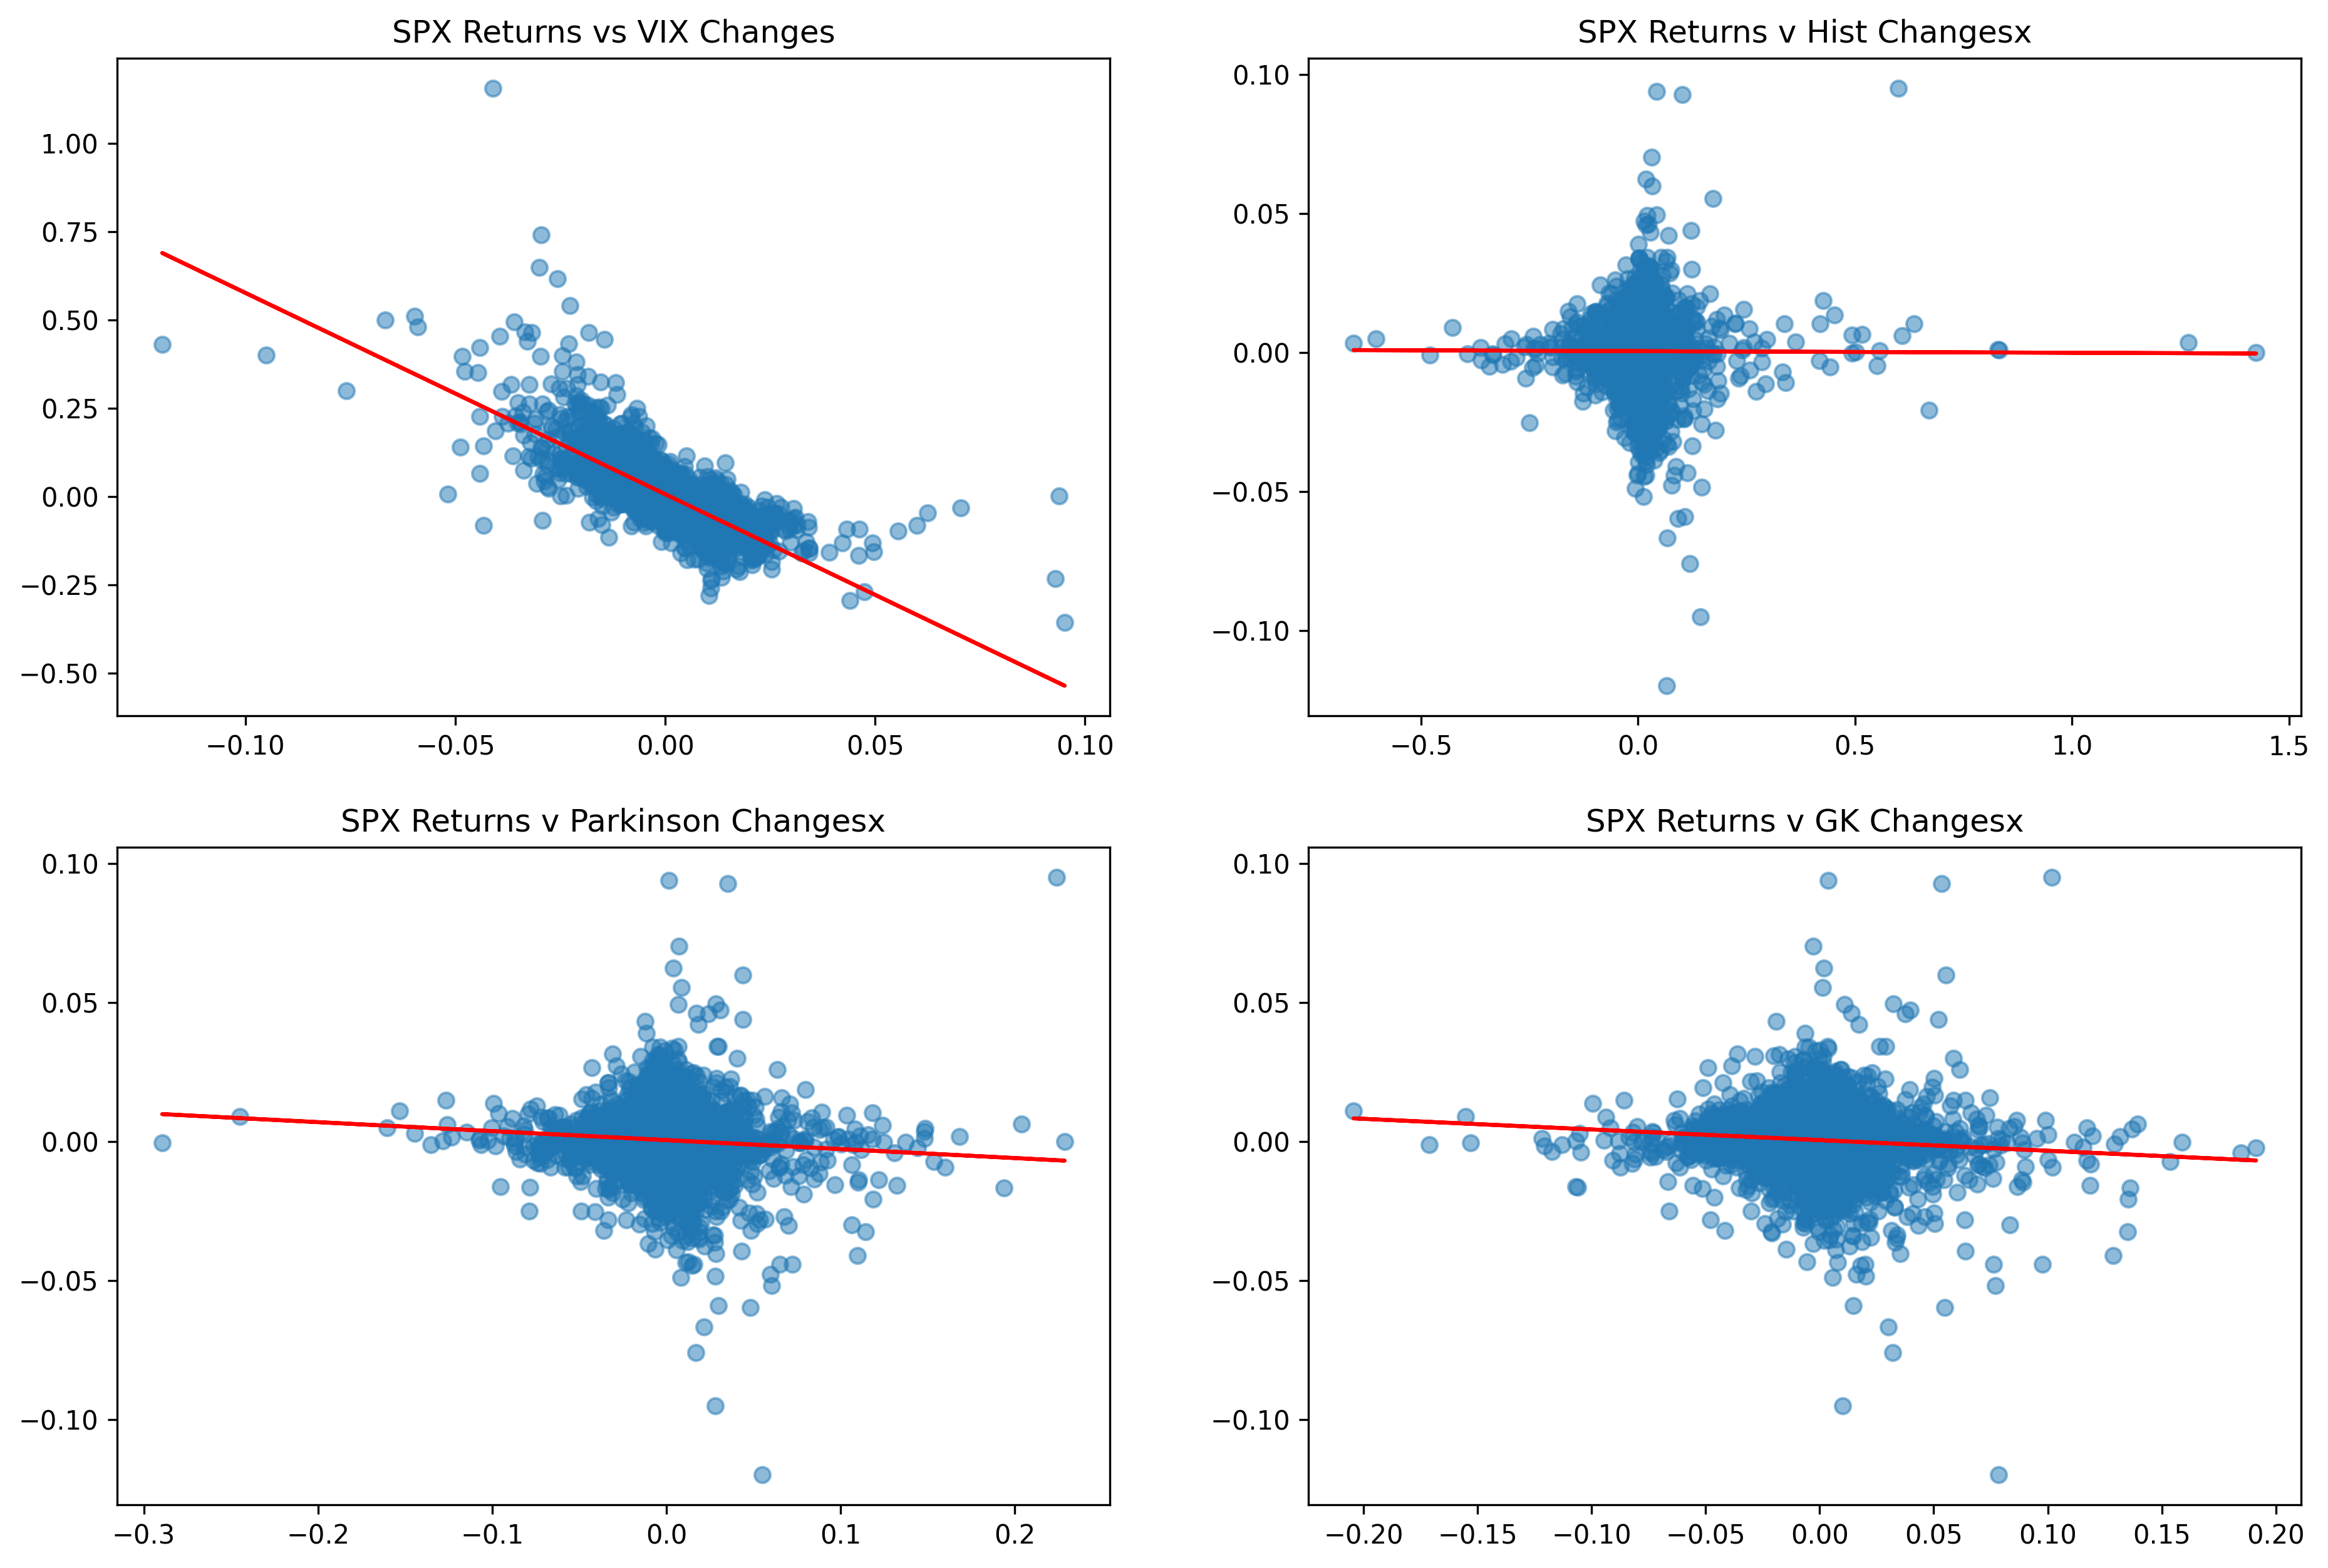

In [ ]:
def _get_df_regression(spx_returns: pd.DataFrame, est: pd.DataFrame) -> pd.DataFrame:
    """Prepare df for regression analysis by merging SPX returns and estimator changes on date index."""
    est_changes = est.pct_change().dropna()
    return pd.concat([spx_returns, est_changes], axis=1).dropna()

def regression_estimators(spx_returns: pd.DataFrame, est: pd.DataFrame):
    """Returns regression model of SPX returns on estimator changes."""
    df_est = _get_df_regression(spx_returns, est)
    cols = df_est.columns
    x = df_est[cols[1]]
    y = df_est[cols[0]]

    return sm.OLS(y, sm.add_constant(x)).fit()

# ---- SPX vs VIX -------
spx_close = fetch_spx_close(start_date, end_date)
vix_close = fetch_vix_close(start_date, end_date)
# get returns and changes
spx_returns = spx_close["Close"].pct_change().dropna()
vix_changes = vix_close["Close"].pct_change().dropna()
# rename columns for clarity
spx_returns = spx_returns.rename(columns={"^GSPC": "SPX"})
vix_changes = vix_changes.rename(columns={"^VIX": "VIX"})

x_spx = spx_returns
y_vix = vix_changes

# regression
model_spx = sm.OLS(y_vix, sm.add_constant(x_spx)).fit()

beta_spx = model_spx.params["SPX"]
alpha_spx = model_spx.params["const"]

# ----- SPX vs Estimators -----
hist_vol_model = regression_estimators(spx_returns, hist_vol)
parkinson_model = regression_estimators(spx_returns, hist_parkinson)
gk_model = regression_estimators(spx_returns, hist_gk)

models = [hist_vol_model, parkinson_model, gk_model]

# ---- Plotting -----
fig = plt.figure(figsize=(15, 10), dpi=300)
gs = fig.add_gridspec(2, 2)
axs1 = fig.add_subplot(gs[0, 0])
axs2 = fig.add_subplot(gs[0, 1])
axs3 = fig.add_subplot(gs[1, 0])
axs4 = fig.add_subplot(gs[1, 1])
it_axs = [axs2, axs3, axs4]

# scatter and line vs vix
axs1.scatter(model_spx.model.exog[:, 1], model_spx.model.endog, alpha=0.5)
axs1.plot(model_spx.model.exog[:, 1], alpha_spx + beta_spx * model_spx.model.exog[:, 1], color="red", label=f"Fit: y={alpha_spx:.4f}+{beta_spx:.4f}*x")
axs1.set_title("SPX Returns vs VIX Changes")

for model, ax in zip(models, it_axs):
    est_name = model.model.exog_names[1]  # get name of estimator from model
    alpha = model.params["const"]
    beta = model.params[est_name]
    x = model.model.exog[:, 1]
    y = model.model.endog
    ax.scatter(x, y, alpha=0.5)
    ax.plot(x, alpha + beta * x, color="red")
    ax.set_title(f"SPX Returns v {est_name} Changesx")

### DISCUSSION HERE